<a href="https://colab.research.google.com/github/madeseor/estructuras-de-bases-de-datos/blob/main/KDtree/KDtree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ARBOL KDtree**

El objetivo es construir un Arbol-KD para desde cero para un servicio de entregar, en el cual me pueda mostrar en un area de 500 metros, cuales de los 10 mil puntos estan en ese radio, o sea sus vecinos mas cercanos.

**OBJETIVO:** Se desea comparar su velocidad con Fuerza Bruta.

Para este se implementa un arbol 2D.





# Desarrollo del Árbol KD

Un **KD-Tree (k-dimensional tree)** es una estructura de datos de partición de espacio para organizar puntos en un espacio k-dimensional. Es particularmente útil para problemas como la búsqueda de vecinos más cercanos o la búsqueda de puntos dentro de un rango determinado, ya que permite realizar estas operaciones de manera más eficiente que una búsqueda lineal (fuerza bruta).

### Funcionamiento de un KD-Tree en 2D

En un espacio 2D, como el que utilizamos para coordenadas (latitud, longitud), un KD-Tree particiona el espacio de manera alternada a lo largo de los ejes. El proceso de construcción y búsqueda sigue estos principios:

1.  **Construcción**: Se toma un conjunto de puntos y se selecciona un eje (inicialmente, por ejemplo, el eje X o latitud). Los puntos se ordenan por este eje, y el punto medio se elige como el nodo raíz del subárbol actual. Este nodo divide el espacio en dos subespacios. Todos los puntos con un valor menor en ese eje van al subárbol izquierdo, y los mayores o iguales van al derecho.
2.  **Alternancia de Ejes**: Para los hijos del nodo raíz, se cambia el eje de división (si el padre dividió por X, los hijos dividirán por Y, y viceversa). Este proceso recursivo continúa hasta que no quedan más puntos para insertar en un subárbol.
3.  **Particiones Ortogonales**: El resultado son una serie de divisiones ortogonales que crean una jerarquía de

### Estructura de los Nodos KD


In [2]:
import math # Importar math para funciones como sqrt (raíz cuadrada)

class KDNode:
    def __init__(self, point, axis, left=None, right=None):
        # El punto de datos que este nodo representa. Es una tupla o lista de coordenadas.
        self.point = point
        # El eje de división (dimensión) que este nodo utiliza para particionar el espacio.
        # en 2D: 0 para el eje X, 1 para el eje Y.
        self.axis = axis
        # Referencia al subárbol izquierdo, que contiene puntos con un valor menor
        # en el eje de división actual que el punto de este nodo.
        self.left = left
        # Referencia al subárbol derecho, que contiene puntos con un valor mayor o igual
        # en el eje de división actual que el punto de este nodo.
        self.right = right

    def __repr__(self):
        # Representación en cadena del nodo.
        return f"KDNode(point={self.point}, axis={self.axis})"

### Estructura del Árbol KD (KDTree)

In [1]:
import math # Importar math para sqrt y funciones trigonométricas

class KDTree:
    # Radio de la Tierra en metros para cálculos de Haversine
    EARTH_RADIUS_METERS = 6371e3

    def __init__(self, k):
        # k: La dimensionalidad de los puntos que se almacenarán en el árbol (para (lat, lon)).
        self.k = k
        # La raíz del árbol KD. Inicialmente es None hasta que se inserta el primer punto.
        self.root = None

    def insert(self, point):
        # Método público para insertar un punto en el árbol.
        # Verifica que la dimensionalidad del punto sea correcta.
        if len(point) != self.k:
            raise ValueError(f"El punto debe tener {self.k} dimensiones.")
        # Llama a la función recursiva para insertar el punto, comenzando desde la raíz y profundidad 0.
        self.root = self._insert_recursive(self.root, point, depth=0)

    def _insert_recursive(self, node, point, depth):
        # Método auxiliar recursivo para insertar un punto.
        # node: El nodo actual en la recursion.
        # point: El punto a insertar.
        # depth: La profundidad actual en el árbol, que determina el eje de división.

        # Caso base: Si el nodo actual es None, hemos encontrado el lugar para insertar el nuevo punto.
        # Creamos un nuevo KDNode y establecemos su eje de división basado en la profundidad.
        if node is None:
            return KDNode(point, axis=depth % self.k)

        # Determina el eje de división para el nodo actual (0 para latitud, 1 para longitud).
        current_axis = node.axis

        # Compara el punto a insertar con el punto del nodo actual en el eje correspondiente.
        if point[current_axis] < node.point[current_axis]:
            # Si es menor, se inserta en el subárbol izquierdo.
            node.left = self._insert_recursive(node.left, point, depth + 1)
        else:
            # Si es mayor o igual, se inserta en el subárbol derecho.
            node.right = self._insert_recursive(node.right, point, depth + 1)
        return node

    def search(self, point):
        # Este es un método de búsqueda exacto para verificar si un punto existe en el árbol.
        # Para búsqueda de vecinos más cercanos (KNN) o búsqueda por rango, se necesitan algoritmos más complejos.
        return self._search_recursive(self.root, point, depth=0)

    def _search_recursive(self, node, point, depth):
        # Método auxiliar recursivo para la búsqueda exacta.

        # Caso base: Si el nodo es None, el punto no se encontró en este camino.
        if node is None:
            return False # No encontrado

        # Caso base: Si el punto del nodo actual es igual al punto buscado, lo hemos encontrado.
        if node.point == point:
            return True # Punto encontrado

        # Determina el eje de división del nodo actual.
        current_axis = node.axis

        # Continúa la búsqueda en el subárbol apropiado.
        if point[current_axis] < node.point[current_axis]:
            return self._search_recursive(node.left, point, depth + 1)
        else:
            return self._search_recursive(node.right, point, depth + 1)

    def build(self, points):
        # Método para construir el árbol a partir de una lista de puntos, usando la mediana para balancear.
        if not points: # Si la lista de puntos está vacía, no hay nada que construir.
            self.root = None
            return
        self.root = self._build_recursive(points, depth=0)

    def _build_recursive(self, points, depth):
        # Método auxiliar recursivo para construir un árbol KD balanceado por mediana.
        if not points:
            return None

        # Determina el eje de división para la profundidad actual.
        current_axis = depth % self.k

        # Ordena los puntos a lo largo del eje actual.
        # Esto es crucial para encontrar la mediana.
        points.sort(key=lambda p: p[current_axis])

        # Encuentra el índice de la mediana.
        median_index = len(points) // 2

        # El punto mediano se convierte en el nodo actual.
        node = KDNode(points[median_index], axis=current_axis)

        # Construye recursivamente los subárboles izquierdo y derecho.
        # El subárbol izquierdo contiene puntos con valores menores que la mediana.
        node.left = self._build_recursive(points[:median_index], depth + 1)
        # El subárbol derecho contiene puntos con valores mayores que la mediana.
        # Excluye el punto mediano de ambos subconjuntos.
        node.right = self._build_recursive(points[median_index + 1:], depth + 1)

        return node

    def print_tree(self):
        # Método para imprimir una representación visual del árbol KD.
        print("\nVisualización del Árbol KD:")
        self._print_tree_recursive(self.root, depth=0)

    def _print_tree_recursive(self, node, depth):
        # Método auxiliar recursivo para imprimir el árbol.
        if node is not None:
            # Crea una sangría para mostrar la profundidad del nodo.
            indent = "  " * depth
            print(f"{indent}Node: {node.point} (Axis: {node.axis})")
            # Si tiene hijos, imprime las ramas izquierda y derecha.
            if node.left or node.right:
                if node.left:
                    print(f"{indent}  Left:")
                    self._print_tree_recursive(node.left, depth + 1)
                if node.right:
                    print(f"{indent}  Right:")
                    self._print_tree_recursive(node.right, depth + 1)

    @staticmethod
    def _haversine_distance(point1, point2):
        # Calcula la distancia Haversine entre dos puntos (latitud, longitud) en metros.
        # point1: (lat1, lon1), point2: (lat2, lon2)
        lat1, lon1 = math.radians(point1[0]), math.radians(point1[1])
        lat2, lon2 = math.radians(point2[0]), math.radians(point2[1])

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

        return KDTree.EARTH_RADIUS_METERS * c

    def find_points_in_radius(self, query_point, radius_meters):
        # Método principal para encontrar todos los puntos dentro de un radio dado.
        # query_point: El punto central desde el cual se busca el radio (latitud, longitud).
        # radius_meters: El tamaño del radio de búsqueda en metros.

        found_points = [] # Lista para almacenar los puntos encontrados.

        # Calcular el radio angular aproximado en grados para la poda.
        # Esto crea un 'bounding box' aproximado para el pruning.
        # La variación en longitud depende de la latitud.
        query_lat_rad = math.radians(query_point[0])
        angular_radius_lat = math.degrees(radius_meters / self.EARTH_RADIUS_METERS) # Radio en grados de latitud
        # Radio en grados de longitud, ajustado por el coseno de la latitud para reflejar la convergencia de meridianos
        angular_radius_lon = math.degrees(radius_meters / (self.EARTH_RADIUS_METERS * math.cos(query_lat_rad)))

        # Utiliza una copia de la lista de puntos para evitar modificar la original durante la recursión
        # (aunque en este caso, points_in_radius_kd es el resultado, no el input).
        self._find_points_in_radius_recursive(self.root, query_point, radius_meters, 0, found_points, angular_radius_lat, angular_radius_lon)
        return found_points

    def _find_points_in_radius_recursive(self, node, query_point, radius_meters, depth, found_points, angular_radius_lat, angular_radius_lon):
        # Método auxiliar recursivo para la búsqueda de puntos en un radio.

        if node is None:
            return

        # 1. Verificar si el punto del nodo actual está dentro del radio de la consulta usando Haversine.
        distance_to_node = self._haversine_distance(node.point, query_point)
        if distance_to_node <= radius_meters:
            found_points.append(node.point)

        # 2. Determinar el eje de división para el nodo actual.
        current_axis = node.axis # 0 para latitud, 1 para longitud

        # 3. Decidir qué subárboles explorar (pruning o poda) usando el radio angular.
        # El rango angular para la poda es diferente para latitud (eje 0) y longitud (eje 1).
        angular_bound = angular_radius_lat if current_axis == 0 else angular_radius_lon

        # Explorar el subárbol izquierdo si la esfera de búsqueda puede intersectar este lado.
        # Comprueba si el rango mínimo de la consulta (query_point - angular_bound) cruza el plano de división del nodo.
        if (query_point[current_axis] - angular_bound) < node.point[current_axis]:
            self._find_points_in_radius_recursive(node.left, query_point, radius_meters, depth + 1, found_points, angular_radius_lat, angular_radius_lon)

        # Explorar el subárbol derecho si la esfera de búsqueda puede intersectar este lado.
        # Comprueba si el rango máximo de la consulta (query_point + angular_bound) cruza el plano de división del nodo.
        if (query_point[current_axis] + angular_bound) > node.point[current_axis]:
             self._find_points_in_radius_recursive(node.right, query_point, radius_meters, depth + 1, found_points, angular_radius_lat, angular_radius_lon)

### 1. Generación de Datos de Puntos de Entrega

In [3]:
import random
import time

n_points = 10000 # Número de puntos de entrega a generar
# Rango de coordenadas latitud y longitud para simular Buenos Aires - Argentina
# Zona grade, lo cual hara que al generar los vecinos tiendan a ser mas pocos.
lat_min, lat_max = -34.7, -34.5
lon_min, lon_max = -58.6, -58.3
k_dim = 2       # Dimensionalidad de los puntos (para (latitud, longitud))

#Generar 10,000 Puntos de Entrega Aleatorios
print(f"Generar {n_points} puntos de entrega aleatorios (Latitud, Longitud)")
delivery_points = []
for _ in range(n_points):
    lat = random.uniform(lat_min, lat_max)
    lon = random.uniform(lon_min, lon_max)
    delivery_points.append((lat, lon))

print(f"Se generaron {len(delivery_points)} puntos de entrega.")

Generar 10000 puntos de entrega aleatorios (Latitud, Longitud)
Se generaron 10000 puntos de entrega.


### 2. Construcción del Árbol KD con los Puntos de Entrega

In [4]:
#Construir el Árbol KD
print("Construyendo el Árbol KD con los puntos de entrega:")
kd_tree = KDTree(k_dim)
kd_tree.build(delivery_points)
print("Árbol KD construido exitosamente.")

Construyendo el Árbol KD con los puntos de entrega:
Árbol KD construido exitosamente.


# Pruebas y Generación de Datos

Esta sección se dedica a la preparación de los datos y a la ejecución de las búsquedas utilizando tanto el KD-Tree implementado como el método de fuerza bruta. El objetivo es simular un escenario real de puntos de entrega y medir el rendimiento de ambos enfoques para encontrar puntos dentro de un radio específico.

### 3. Búsqueda de Puntos en un Radio de 500m (Usando KD-Tree)

In [5]:
#Definir el Punto de Consulta y el Radio
# Generar un punto de consulta aleatorio dentro del rango de nuestros delivery_points
query_point = (random.uniform(lat_min, lat_max), random.uniform(lon_min, lon_max)) # Un punto aleatorio para consultar
radius_meters = 500 # Radio de búsqueda en metros
print(f"\nPunto de consulta: {query_point}, Radio: {radius_meters} metros")

#Búsqueda usando KD
print("Realizando búsqueda por radio con KD-Tree")
start_time_kd = time.time()
points_in_radius_kd = kd_tree.find_points_in_radius(query_point, radius_meters)
end_time_kd = time.time()

print(f"Puntos encontrados con KD-Tree: {len(points_in_radius_kd)}")
print(f"Tiempo de ejecución (KD-Tree): {end_time_kd - start_time_kd:.6f} segundos")
# Muestra los primeros 5 puntos si hay muchos, o todos si son pocos.
if len(points_in_radius_kd) > 5:
    print("Primeros 5 puntos encontrados (KD-Tree):", points_in_radius_kd[:5], ".")
else:
    print("Puntos encontrados (KD-Tree):", points_in_radius_kd)


Punto de consulta: (-34.59377278171143, -58.388074913564054), Radio: 500 metros
Realizando búsqueda por radio con KD-Tree
Puntos encontrados con KD-Tree: 9
Tiempo de ejecución (KD-Tree): 0.000338 segundos
Primeros 5 puntos encontrados (KD-Tree): [(-34.592344546121815, -58.3929485194451), (-34.591983544583094, -58.38323956947595), (-34.59600144047691, -58.390365824032806), (-34.5967163718551, -58.391072803282526), (-34.5934097248053, -58.3918683219479)] .


### 4. Búsqueda de Puntos en un Radio (Fuerza Bruta para Comparación)

### 5. Escenario donde la Fuerza Bruta es más rápida (menos eficiente el KD-Tree)

Para ilustrar una situación donde el KD-Tree podría ser menos eficiente que la búsqueda por fuerza bruta, generaremos un número muy pequeño de puntos. En estos casos, la sobrecarga computacional de construir y recorrer la estructura del árbol puede superar los beneficios de su eficiencia algorítmica, haciendo que un simple recorrido lineal sea más rápido.

IMOPRTANTE: para lograr esto cambiamos a N dimensiones, 50D y 10 datos.

In [14]:
import random
import time
import math # Importar math para euclidean_distance

# Definir una función de distancia euclidiana para N dimensiones
def euclidean_distance(point1, point2):
    # Calcula la distancia euclidiana entre dos puntos N-dimensionales.
    return math.sqrt(sum((p1 - p2)**2 for p1, p2 in zip(point1, point2)))

# Redefinir KDTree para esta prueba específica, usando distancia euclidiana y manejando dimensiones más altas
# Esta es una versión simplificada para la prueba para evitar modificar la clase principal KDTree
# y para manejar correctamente puntos 4D con distancia euclidiana.
class KDNodeTest:
    def __init__(self, point, axis, left=None, right=None):
        self.point = point
        self.axis = axis
        self.left = left
        self.right = right

class KDTreeTest:
    def __init__(self, k, distance_func):
        self.k = k
        self.root = None
        self.distance_func = distance_func # Hacer que la función de distancia sea configurable

    def build(self, points):
        if not points:
            self.root = None
            return
        self.root = self._build_recursive(list(points), depth=0) # Pasar una copia para evitar modificar la lista original

    def _build_recursive(self, points, depth):
        if not points:
            return None

        current_axis = depth % self.k
        points.sort(key=lambda p: p[current_axis])
        median_index = len(points) // 2
        node = KDNodeTest(points[median_index], axis=current_axis)

        node.left = self._build_recursive(points[:median_index], depth + 1)
        node.right = self._build_recursive(points[median_index + 1:], depth + 1)
        return node

    def find_points_in_radius(self, query_point, radius):
        found_points = []
        self._find_points_in_radius_recursive(self.root, query_point, radius, 0, found_points)
        return found_points

    def _find_points_in_radius_recursive(self, node, query_point, radius, depth, found_points):
        if node is None:
            return

        # Comprobar la distancia al punto del nodo
        distance_to_node = self.distance_func(node.point, query_point)
        if distance_to_node <= radius:
            found_points.append(node.point)

        current_axis = node.axis

        # Comprobación para distancia euclidiana:
        # Si el plano de división está más cerca del punto de consulta que el radio,
        # necesitamos verificar ambos lados. De lo contrario, solo podríamos necesitar verificar un lado.
        # En dimensiones altas, esta poda a menudo se vuelve menos efectiva.
        dist_to_plane = abs(query_point[current_axis] - node.point[current_axis])

        # Buscar recursivamente el hijo izquierdo si su región delimitadora podría intersecar la esfera de búsqueda
        if query_point[current_axis] - radius <= node.point[current_axis]:
            self._find_points_in_radius_recursive(node.left, query_point, radius, depth + 1, found_points)

        # Buscar recursivamente el hijo derecho si su región delimitadora podría intersecar la esfera de búsqueda
        if query_point[current_axis] + radius >= node.point[current_axis]:
            self._find_points_in_radius_recursive(node.right, query_point, radius, depth + 1, found_points)


# CONDICIONES DE LA PRUEBA
n_points_small = 10 # Número de puntos (manteniéndolo muy bajo)
k_dim_small_test = 50 # Dimensionalidad aumentada drásticamente para demostrar la maldición de la dimensionalidad

# Generar puntos N-dimensionales (por ejemplo, en un rango de 0 a 1)
delivery_points_small = []
for _ in range(n_points_small):
    point = tuple(random.uniform(0, 1) for _ in range(k_dim_small_test)) # Puntos en el rango 0-1
    delivery_points_small.append(point)

print(f"\nGenerando {n_points_small} puntos {k_dim_small_test}-dimensionales para el escenario de prueba (Fuerza Bruta vs KD-Tree, donde FB puede ser más eficiente). Llegando a la maldición de la dimensionalidad.")

# Construir el árbol KD para alta dimensión usando distancia euclidiana
kd_tree_small = KDTreeTest(k_dim_small_test, euclidean_distance)
kd_tree_small.build(delivery_points_small)
print(f"Árbol KD pequeño construido ({k_dim_small_test}D, Euclideana).")

# Definir un punto de consulta y un radio para esta prueba
# Seleccionar un punto de consulta de la lista generada para asegurar resultados
query_point_small = random.choice(delivery_points_small)
radius_small_test = 0.5 # Un radio más grande para hacer que la poda sea menos efectiva
print(f"Punto de consulta para prueba pequeña: {query_point_small}, Radio: {radius_small_test} (Euclideana)")

# Búsqueda usando KD-Tree
print(f"Realizando búsqueda por radio con KD-Tree (datos muy pequeños, {k_dim_small_test}D):")
start_time_kd_small = time.time()
points_in_radius_kd_small = kd_tree_small.find_points_in_radius(query_point_small, radius_small_test)
end_time_kd_small = time.time()

print(f"Puntos encontrados con KD-Tree (pequeño): {len(points_in_radius_kd_small)}")
print(f"Tiempo de ejecución (KD-Tree, pequeño): {end_time_kd_small - start_time_kd_small:.8f} segundos")

# Búsqueda por Fuerza Bruta
print(f"\nRealizando búsqueda por radio con Fuerza Bruta (datos muy pequeños, {k_dim_small_test}D):")
start_time_brute_small = time.time()
points_in_radius_brute_small = []
for p in delivery_points_small:
    if euclidean_distance(p, query_point_small) <= radius_small_test:
        points_in_radius_brute_small.append(p)
end_time_brute_small = time.time()

print(f"Puntos encontrados con Fuerza Bruta (pequeño): {len(points_in_radius_brute_small)}")
print(f"Tiempo de ejecución (Fuerza Bruta, pequeño): {end_time_brute_small - start_time_brute_small:.8f} segundos")

print(f"\nCoinciden los resultados (escenario muy pequeño, {k_dim_small_test}D): {set(points_in_radius_kd_small) == set(points_in_radius_brute_small)}")

comparison_message = "más rápida" if (end_time_brute_small - start_time_brute_small) < (end_time_kd_small - start_time_kd_small) else "más lenta"
print(f"\nEn este escenario con {n_points_small} puntos y {k_dim_small_test} dimensiones, la Fuerza Bruta ({end_time_brute_small - start_time_brute_small:.8f}s) es {comparison_message} que el KD-Tree ({end_time_kd_small - start_time_kd_small:.8f}s) debido a la sobrecarga del algoritmo del KD-Tree para conjuntos de datos muy pequeños y/o mayor dimensionalidad.")


Generando 10 puntos 50-dimensionales para el escenario de prueba (Fuerza Bruta vs KD-Tree, donde FB puede ser más eficiente). وصلت a la maldición de la dimensionalidad.
Árbol KD pequeño construido (50D, Euclideana).
Punto de consulta para prueba pequeña: (0.2546334680507535, 0.7282976921799947, 0.7513120274676549, 0.9005067216304038, 0.9933387977611793, 0.8616812378381886, 0.8317542643675232, 0.024262781498133323, 0.8460955178687959, 0.46843489639468605, 0.915464720312698, 0.9375515553206049, 0.2875439641728613, 0.4154383570271487, 0.7413033101873587, 0.15553246808243293, 0.6034674362351651, 0.47717435143683706, 0.9941794499993133, 0.24736845237586158, 0.5738508254607477, 0.05058805950869838, 0.7758704744714027, 0.4509041088892023, 0.11496180613744234, 0.8672149972056478, 0.9129482925339321, 0.9335410659628567, 0.2123724071924552, 0.37104705581668973, 0.48125953149025746, 0.3798284291007423, 0.2683455827051082, 0.5371605354474772, 0.010525442848781208, 0.015945039275803374, 0.17929757

In [6]:
# --- Función Auxiliar para Distancia Haversine (para fuerza bruta) ---
def haversine_distance(point1, point2):
    # Reutilizamos el método estático del KDTree para la consistencia
    return KDTree._haversine_distance(point1, point2)

# --- Búsqueda por Fuerza Bruta ---
print("\nRealizando búsqueda por radio con Fuerza Bruta:")
start_time_brute = time.time()
points_in_radius_brute = []
for p in delivery_points:
    if haversine_distance(p, query_point) <= radius_meters:
        points_in_radius_brute.append(p)
end_time_brute = time.time()

print(f"Puntos encontrados con Fuerza Bruta: {len(points_in_radius_brute)}")
print(f"Tiempo de ejecución (Fuerza Bruta): {end_time_brute - start_time_brute:.6f} segundos")
# Muestra los primeros 5 puntos si hay muchos, o todos si son pocos.
if len(points_in_radius_brute) > 5:
    print("Primeros 5 puntos encontrados (Fuerza Bruta):", points_in_radius_brute[:5], "...")
else:
    print("Puntos encontrados (Fuerza Bruta):", points_in_radius_brute)

#Verificación de Resultados (Opcional)
print(f"Coinciden los resultados: {set(points_in_radius_kd) == set(points_in_radius_brute)}")


Realizando búsqueda por radio con Fuerza Bruta:
Puntos encontrados con Fuerza Bruta: 9
Tiempo de ejecución (Fuerza Bruta): 0.016816 segundos
Primeros 5 puntos encontrados (Fuerza Bruta): [(-34.5967163718551, -58.391072803282526), (-34.59600144047691, -58.390365824032806), (-34.59352343443946, -58.39158082035383), (-34.5934097248053, -58.3918683219479), (-34.592344546121815, -58.3929485194451)] ...
Coinciden los resultados: True


# Visualizaciones

Para comprender mejor los resultados de la búsqueda por radio y confirmar la precisión de la implementacióN, esta sección presenta visualizaciones de los puntos generados, el punto de consulta y los puntos identificados dentro del radio especificado. Esto nos permite verificar visualmente que el algoritmo está funcionando correctamente y entender la distribución espacial de los datos.

**Tenemos dos tipos de visualizaciones diferentes:** Una con una vista general que contiene los 10 mil puntos generados y utilizados para las pruebas, y otra, que es una vision unica del radio de 500 metros.


**IMPORTANTE:** Recordar que el area en el que se esta trabajando es amplica, se trata de una locacion (lat, long) de Benos Aires, Argentina. esto es importante porque responde a la pregunta de ¿por que hay tan pocos puntos dentro del circulo y a sus alrededores? esto se debe a que el area es muy grande y por ende la distribucion es mayor.

### 5. Verificación Visual de la Búsqueda por Radio

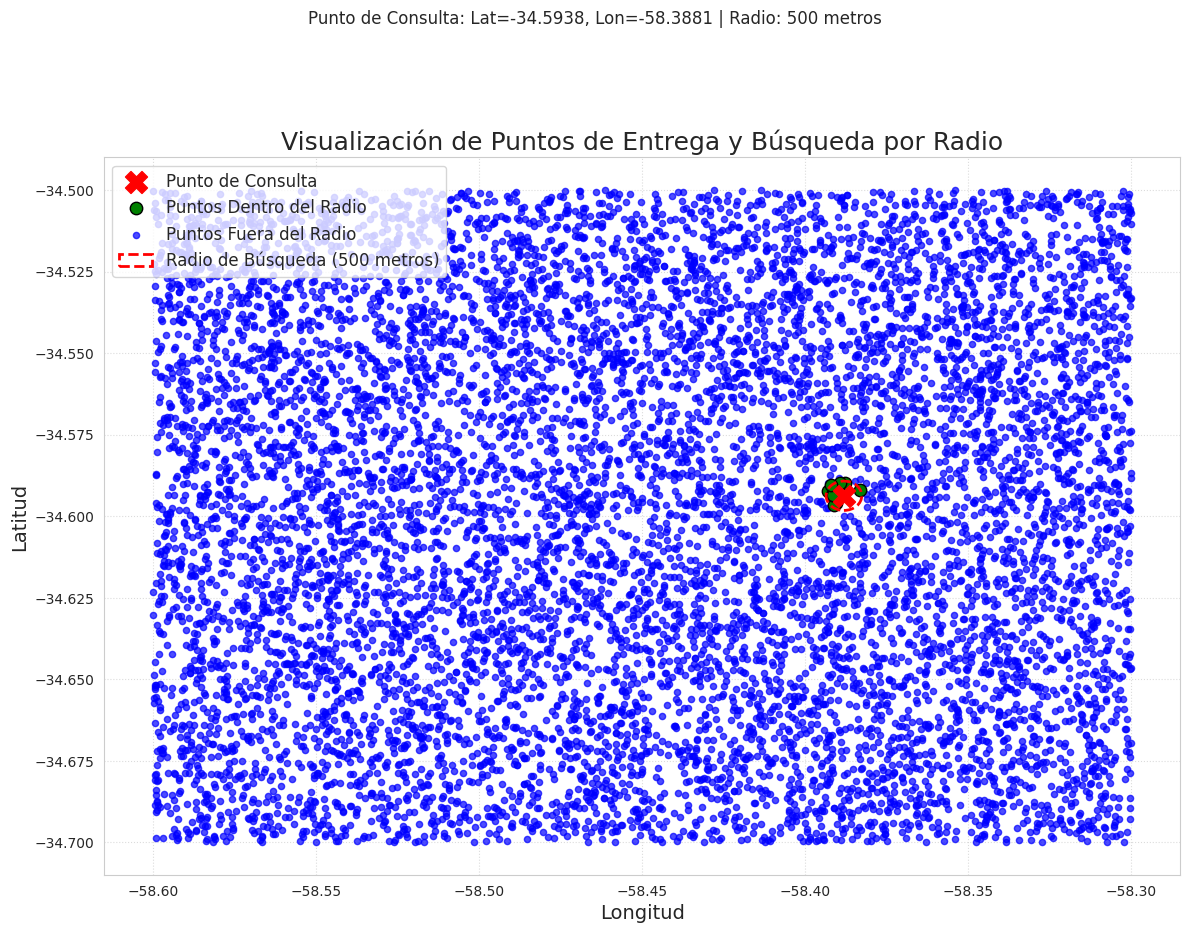

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import numpy as np

# Recalcular radios angulares para la visualización, ya que se necesitan en grados
# para dibujar la elipse que representa el área de búsqueda.
# query_point, radius_meters, KDTree.EARTH_RADIUS_METERS ya están definidos y disponibles.
query_lat_rad = math.radians(query_point[0])
angular_radius_lat_deg = math.degrees(radius_meters / KDTree.EARTH_RADIUS_METERS)
angular_radius_lon_deg = math.degrees(radius_meters / (KDTree.EARTH_RADIUS_METERS * math.cos(query_lat_rad)))

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Convertir listas de tuplas a arrays de NumPy para facilitar el ploteo
delivery_points_np = np.array(delivery_points)
points_in_radius_np = np.array(points_in_radius_kd)

# 1. Plotear el punto de consulta (rojo, cruz grande)
plt.scatter(query_point[1], query_point[0], color='red', marker='X', s=250, label='Punto de Consulta', zorder=5)

# 2. Plotear los puntos encontrados dentro del radio (verde, más grandes)
if len(points_in_radius_np) > 0:
    plt.scatter(points_in_radius_np[:, 1], points_in_radius_np[:, 0], s=80, color='green', label='Puntos Dentro del Radio', zorder=4, edgecolor='black')

# 3. Plotear los puntos fuera del radio (azul, pequeños)
# Calculamos los puntos que no están en points_in_radius_kd
# Convertimos a conjunto para una comparación eficiente, luego de vuelta a lista para NumPy
set_points_in_radius = set(points_in_radius_kd)
points_outside_radius = [p for p in delivery_points if p not in set_points_in_radius]
points_outside_radius_np = np.array(points_outside_radius)
if len(points_outside_radius_np) > 0:
    plt.scatter(points_outside_radius_np[:, 1], points_outside_radius_np[:, 0], s=20, color='blue', alpha=0.7, label='Puntos Fuera del Radio', zorder=3)

# 4. Dibujar el círculo de radio alrededor del punto de consulta
# Usamos una elipse para aproximar el círculo en coordenadas de lat/lon
# debido a la distorsión de la proyección. Los 'angular_radius_lon_deg' y 'angular_radius_lat_deg'
# ya están escalados correctamente para el grado de latitud de la consulta.
circle_patch = Ellipse((query_point[1], query_point[0]),
                       width=2 * angular_radius_lon_deg, # 2 * radio angular en longitud
                       height=2 * angular_radius_lat_deg, # 2 * radio angular en latitud
                       angle=0, color='red', fill=False, linestyle='--', linewidth=2, zorder=6,
                       label=f'Radio de Búsqueda ({radius_meters} metros)')
plt.gca().add_patch(circle_patch)

# Configuración de la gráfica
plt.title('Visualización de Puntos de Entrega y Búsqueda por Radio', fontsize=18)
plt.suptitle(f'Punto de Consulta: Lat={query_point[0]:.4f}, Lon={query_point[1]:.4f} | Radio: {radius_meters} metros', fontsize=12)
plt.xlabel('Longitud', fontsize=14)
plt.ylabel('Latitud', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box') # Mantiene la proporción para que el círculo se vea bien
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el supertítulo no se solape
plt.show()

### 6. Verificación Visual Detallada del Radio de Búsqueda

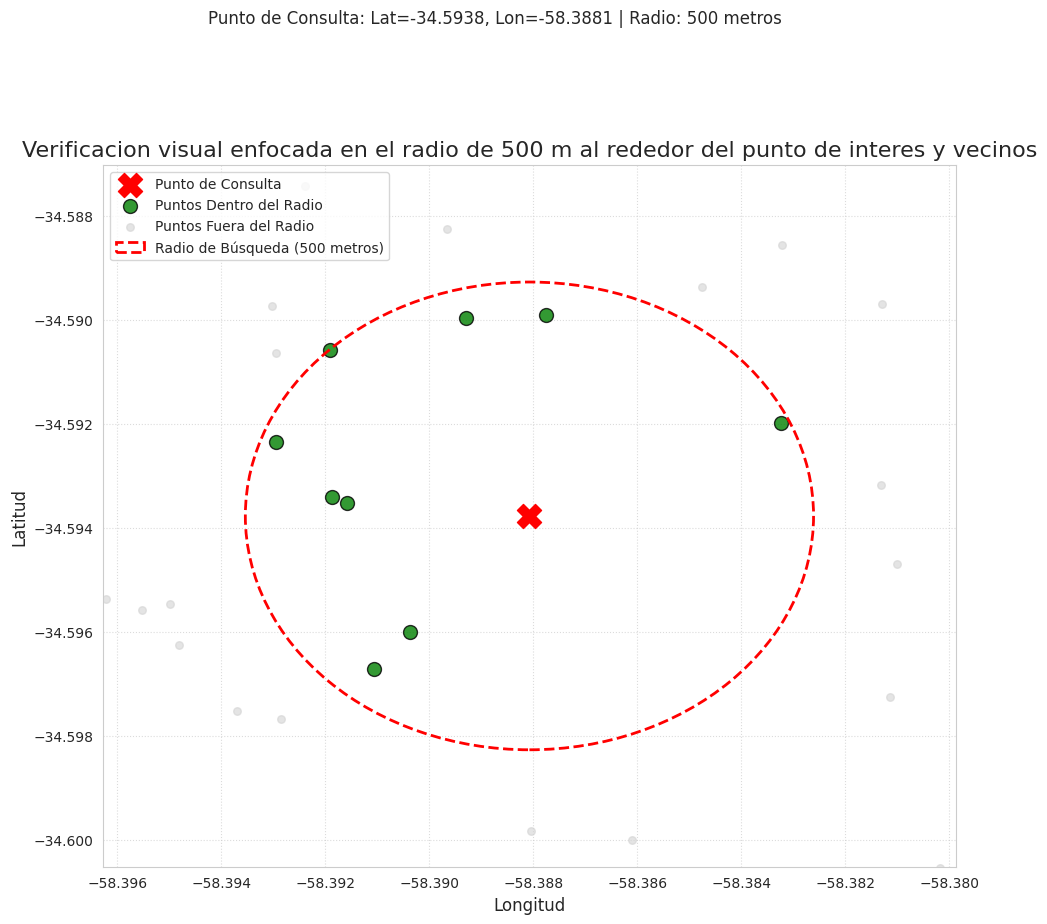

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import numpy as np

# Los radios angulares ya están calculados y disponibles de la celda anterior:
# query_point, radius_meters, angular_radius_lat_deg, angular_radius_lon_deg

plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")

# Convertir listas de tuplas a arrays de NumPy para facilitar el ploteo
# Se necesita delivery_points para calcular los puntos fuera del radio
delivery_points_np = np.array(delivery_points)
points_in_radius_np = np.array(points_in_radius_kd)

# 1. Plotear el punto de consulta (rojo, cruz grande)
plt.scatter(query_point[1], query_point[0], color='red', marker='X', s=300, label='Punto de Consulta', zorder=5)

# 2. Plotear los puntos encontrados dentro del radio (verde, más grandes)
if len(points_in_radius_np) > 0:
    plt.scatter(points_in_radius_np[:, 1], points_in_radius_np[:, 0], s=100, color='green', label='Puntos Dentro del Radio', zorder=4, edgecolor='black', alpha=0.8)

# 3. Plotear los puntos fuera del radio (gris claro, pequeños)
# Calculamos los puntos que no están en points_in_radius_kd
set_points_in_radius = set(points_in_radius_kd)
points_outside_radius = [p for p in delivery_points if p not in set_points_in_radius]
points_outside_radius_np = np.array(points_outside_radius)
if len(points_outside_radius_np) > 0:
    plt.scatter(points_outside_radius_np[:, 1], points_outside_radius_np[:, 0], s=30, color='lightgray', alpha=0.6, label='Puntos Fuera del Radio', zorder=2)

# 4. Dibujar el círculo de radio alrededor del punto de consulta
circle_patch = Ellipse((query_point[1], query_point[0]),
                       width=2 * angular_radius_lon_deg,
                       height=2 * angular_radius_lat_deg,
                       angle=0, color='red', fill=False, linestyle='--', linewidth=2, zorder=6,
                       label=f'Radio de Búsqueda ({radius_meters} metros)')
plt.gca().add_patch(circle_patch)

# Configuración de la gráfica para un zoom más cercano
plt.title('Verificacion visual enfocada en el radio de 500 m al rededor del punto de interes y vecinos', fontsize=16)
plt.suptitle(f'Punto de Consulta: Lat={query_point[0]:.4f}, Lon={query_point[1]:.4f} | Radio: {radius_meters} metros', fontsize=12)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box') # Mantiene la proporción

# Establecer límites de los ejes para hacer un zoom alrededor del query_point y el radio
# Añadimos un pequeño margen para que el círculo no esté pegado al borde
margin_lat = angular_radius_lat_deg * 1.5 # 50% más grande que el radio para el margen
margin_lon = angular_radius_lon_deg * 1.5

plt.xlim(query_point[1] - margin_lon, query_point[1] + margin_lon)
plt.ylim(query_point[0] - margin_lat, query_point[0] + margin_lat)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el supertítulo no se solape
plt.show()

# Análisis y Conclusiones

En esta sección, se analizan los resultados obtenidos de las pruebas de rendimiento del KD-Tree frente a la búsqueda por fuerza bruta. Se busca responder a la pregunta fundamental: ¿En qué condiciones un KD-Tree supera en velocidad a una búsqueda por fuerza bruta y por qué?

Como podemos observar en nuestras pruebas unitarias tenemos que el tiemo del KD-Tree es de 0.000338 segundos frente al resultado de busqueda obtenido por Fuerza Bruta que fue de 0.016816 segundos.

Esto nos evidencia que el KD-Tree es mucho mas eficiente cuando tenemos una **dimensionalidad baja** y un conjunto de datos grande (10 mil en este caso), por lo que en este caso donde estamos haciendo varias consultas va a resultar mucho mas eficiente ya que contamos con una dimension 2D.

Cuando no se cumplen estas condiciones para el arbol KD, este empieza a ser lento y menos eficiente, siendo entonces mejor la fuerza bruta. Esto lo evidenciamos en el escenario en donde teniendo una dimension de 50D, con solo 10 datos, el bolr kd pasa a ser menos eficiente que usar fuerza bruta.